In [1]:
# Add parent directory to path for local imports
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

In [ ]:
# 3rd party imports
import torch
import numpy as np
from torch import nn as NN
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

In [3]:
# local imports
from settings import Constants
from neural_net import StockModel
from dataframe_handler import DataManager
from binance_api.indicators import RSI, BollingerBands, ATR, VWAP

In [4]:
# --------------------------------------------------
# GLOBAL SPEED SETTINGS
# --------------------------------------------------
DEVICE = Constants.DEVICE

In [5]:
# --------------------------------------------------
# HYPER PARAMETERS (Modify these as needed)
# --------------------------------------------------

# FILE paths
CSV_FILE_NAME = Constants.CSV_FILE_PATH
PROCESSED_FILE_NAME = Constants.PROCESSED_FILE_PATH

# DATASET parameters
COL_LAGS = Constants.COL_LAGS
TRAIN_RATIO = Constants.TRAIN_RATIO
ATR_COL_NAME = Constants.ATR_COL_NAME
SCALABLE_COLS = Constants.SCALABLE_COLS
COLS_TO_STACK = Constants.COLS_TO_STACK
REWARD_RATIO = Constants.R_MULTIPLE_REWARD
COLS_TO_DROP = Constants.COLS_TO_DROP
MAX_ALLOWED_TRADE_LENGTH = Constants.MAX_ALLOWED_TRADE_LENGTH
TARGET_COL = Constants.TARGET_COL

# Model architecture
DROPOUT = Constants.DROPOUT
FC1_INPUT_SIZE = Constants.FC1_INPUT_SIZE
FC2_INPUT_SIZE = Constants.FC2_INPUT_SIZE

# Training parameters
EPOCHS = Constants.EPOCHS
BATCH_SIZE = Constants.BATCH_SIZE
LEARNING_RATE = Constants.LEARNING_RATE
GRADIENT_CLIP = Constants.GRADIENT_CLIP
VAL_PATIENCE = Constants.VAL_PATIENCE

# Model save path
MODEL_SAVE_PATH = Constants.MODEL_SAVE_PATH


In [ ]:
# -------------------------------------
# PROCESS RAW FILE
# -------------------------------------

# create indicators
bband = BollingerBands(20)
vwap = VWAP()
atr = ATR(14)
rsi = RSI(14)
indicators = [bband, vwap, atr, rsi]

# create datafram manager
dm = DataManager(
    device=DEVICE,
    split_ratio=TRAIN_RATIO,
    csv_file=CSV_FILE_NAME
)

# implement preprocessing
dm.compute_indicators(
    indicators=indicators,
)

# add r-multiple-cols
dm.add_r_multiple(
    trade_length=MAX_ALLOWED_TRADE_LENGTH,
    atr_col_name=ATR_COL_NAME,
    reward_r=REWARD_RATIO,
)

# scale columns
dm.scale_cols(cols=SCALABLE_COLS)

# stack features
dm.stack_features(
    feature_cols=COLS_TO_STACK,
    lags=COL_LAGS,
)

# drop columns
dm.df.drop(columns=COLS_TO_DROP, inplace=True)

# save to a file
dm.df.to_csv(PROCESSED_FILE_NAME, index=False)
print(f"Processed data saved to {PROCESSED_FILE_NAME}")

In [6]:
dm = DataManager(
    device=DEVICE,
    split_ratio=TRAIN_RATIO,
    csv_file=PROCESSED_FILE_NAME,
)

# extract train and test
trainX, trainY = dm.get_train_tensors(TARGET_COL)
testX, testY = dm.get_test_tensors(TARGET_COL)

# setup training dataset
train_dataset = TensorDataset(trainX, trainY)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=False,
)

# setup testing dataset
test_dataset = TensorDataset(testX, testY)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=False,
)

INPUT_SIZE = trainX.shape[1]
print(f"The model will have {INPUT_SIZE} input features.")

The model will have 39 input features.


In [ ]:
# --------------------------------------------------
# TRAIN WITH EARLY STOPPING
# --------------------------------------------------

# create the model for direction classification
model = StockModel(
    fc1_input_size=FC1_INPUT_SIZE,
    fc2_input_size=FC2_INPUT_SIZE,
    dropout=DROPOUT,
    device=DEVICE,
)

# create optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

# create learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

# create loss function
criterion = NN.HuberLoss()

# create a scaler for mixed precision
scaler = torch.amp.GradScaler(enabled=(DEVICE == "cuda"))

# early stopping variables
best_val_mae = float('inf')
patience_counter = 0
best_model_state = None

# get actual values for validation
actual_r_multiple_values = testY[:, 0].cpu().numpy().reshape(-1, 1)

# train loop
for epoch in range(EPOCHS):

    # switch modes
    model.train()
    total_loss = 0.0
    avg_loss = 0.0

    # train loop
    for x_batch, y_batch in train_loader:

        # reset gradient
        optimizer.zero_grad(set_to_none=True)

        # forward pass
        with torch.amp.autocast(device_type="cuda", enabled=(DEVICE == "cuda")):
            preds = model(x_batch)
            loss = criterion(preds, y_batch)

            if not torch.isfinite(loss):
                continue

        # backprop
        scaler.scale(loss).backward()

        # gradient clipping
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP)

        # take a step
        scaler.step(optimizer)
        scaler.update()

        # track metrics
        total_loss += loss.item()

    # calculate average loss
    avg_loss = total_loss / len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    r_preds = []

    # validation loop
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            preds = model(x_batch)
            r_preds.append(preds.cpu())

    # calculate metrics
    r_preds = torch.cat(r_preds).numpy()
    mae = np.mean(np.abs(r_preds - actual_r_multiple_values))

    # step scheduler on validation metric
    scheduler.step(mae)

    # early stopping
    if mae < best_val_mae:
        best_val_mae = mae
        patience_counter = 0
        best_model_state = {
            k: v.detach().cpu().clone()
            for k, v in model.state_dict().items()
        }
    else:
        patience_counter += 1

    print(f"Epoch {epoch+1} | Train Loss {avg_loss:.6f} | Val MAE {mae:.6f}")

    # early stopping
    if patience_counter >= VAL_PATIENCE:
        break

# restore best model
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model with validation MAE: {best_val_mae:.8f}")

AssertionError: Attempted update but _scale is None.  This may indicate your script did not use scaler.scale(loss or outputs) earlier in the iteration.

In [23]:
# --------------------------------------------------
# FINAL EVALUATION
# --------------------------------------------------

# load model if not already loaded
if "model" not in locals():
    model = torch.jit.load(MODEL_SAVE_PATH, map_location=DEVICE)
    model.to(DEVICE)
model.eval()

r_multiple_preds = []

# with no gradient
with torch.no_grad():

    # iterate
    for i in range(0, len(testX), BATCH_SIZE):

        # get current batch
        x_batch = testX[i : i + BATCH_SIZE]

        # model returns r_multiple predictions
        pred = model(x_batch)
        r_multiple_preds.extend(pred.cpu().tolist())

# calculate final regression metrics
actual_r_multiples = testY[:, 0].cpu().tolist()
predicted_r_multiples = [p[0] for p in r_multiple_preds]  # flatten predictions

# MAE
final_mae = np.mean(np.abs(np.array(predicted_r_multiples) - np.array(actual_r_multiples)))

# MSE
final_mse = np.mean((np.array(predicted_r_multiples) - np.array(actual_r_multiples)) ** 2)

# R² score
ss_res = np.sum((np.array(actual_r_multiples) - np.array(predicted_r_multiples)) ** 2)
ss_tot = np.sum((np.array(actual_r_multiples) - np.mean(actual_r_multiples)) ** 2)
r2_score = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

# Accuracy within thresholds
threshold_01 = np.mean(np.abs(np.array(predicted_r_multiples) - np.array(actual_r_multiples)) <= 0.1)
threshold_05 = np.mean(np.abs(np.array(predicted_r_multiples) - np.array(actual_r_multiples)) <= 0.5)
threshold_10 = np.mean(np.abs(np.array(predicted_r_multiples) - np.array(actual_r_multiples)) <= 1.0)

print(f"Final Test MAE: {final_mae:.4f}")
print(f"Final Test MSE: {final_mse:.4f}")
print(f"Final Test R²: {r2_score:.4f}")
print(f"Accuracy within ±0.1: {threshold_01:.4f}")
print(f"Accuracy within ±0.5: {threshold_05:.4f}")
print(f"Accuracy within ±1.0: {threshold_10:.4f}")

Final Test MAE: 1.0164
Final Test MSE: 1.6920
Final Test R²: -0.0395
Accuracy within ±0.1: 0.0407
Accuracy within ±0.5: 0.2764
Accuracy within ±1.0: 0.6773


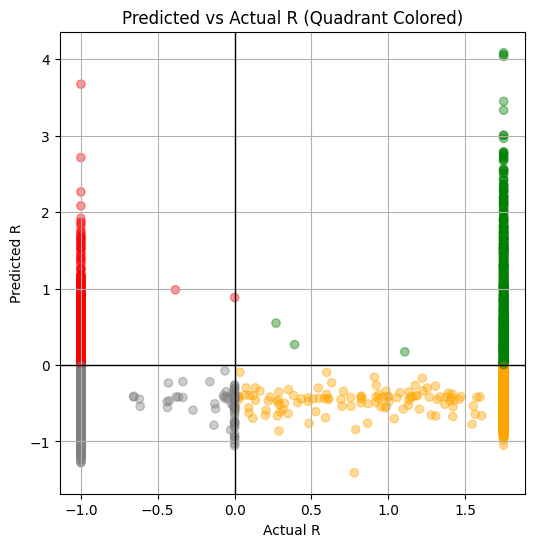

In [22]:
actual = np.asarray(actual_r_multiples)
pred = np.asarray(predicted_r_multiples)

colors = np.where(
    (pred > 0) & (actual > 0), "green",      # good trades
    np.where(
        (pred > 0) & (actual <= 0), "red",    # false positives
        np.where(
            (pred <= 0) & (actual > 0), "orange",  # missed winners
            "gray"                             # correct rejects
        )
    )
)

plt.figure(figsize=(6, 6))
plt.scatter(actual, pred, c=colors, alpha=0.4)
plt.axhline(0, color="black", linewidth=1)
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Actual R")
plt.ylabel("Predicted R")
plt.title("Predicted vs Actual R (Quadrant Colored)")
plt.grid(True)
plt.show()


In [ ]:
# --------------------------------------------------
# SAVE MODEL
# --------------------------------------------------

# save model
traced_model = torch.jit.script(model)
torch.jit.save(traced_model, MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")